# Dataset Preparation

- Create atoms objects for guess structures
- output: pd.series of ase objects pr pymatgen objects
- calculate garget property for learning set: formation energies


In [1]:
from Tools.DatasetTools.Commoms import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor
from mendeleev import element
import matplotlib.legend

In [2]:
import matplotlib

In [3]:
from matplotlib import colormaps

In [4]:
from matplotlib.lines import Line2D
plt.rc('font', size=18)
plt.rc('xtick', labelsize=22)
plt.rc('ytick', labelsize=22)
plt.rc('lines', linewidth=3)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('axes', labelsize=26)
plt.rc('figure', figsize=(10,8))

In [5]:
from mp_api.client import MPRester

# options 

In [6]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
cases = ['POSCAR.initial', 'POSCAR.relaxed-all']
rescale_by_atoms = True #  False]
subcases = ['rescaled',  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')

In [7]:
MP_keys = {'Fe' : 'mp-13', 'Mo' : 'mp-129'}

In [8]:
BS = pd.read_pickle(CuratedBS)

In [9]:
bcc_bs = BS.loc[BS.index.str.contains('Fe.*bcc.*FM', regex=True)]

In [10]:
bcc_bs

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.255228,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,11.356868,Fe_pv,,1,0,1,1.0,0.0,FM,bcc
Fe_pv2.bcc-cubic.FM,bulk bcc-cubic.FM,11.367016 A,-8.254731,187.308419 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.015,0,1,...,11.375458,Fe_pv,,2,0,2,1.0,0.0,FM,bcc


In [11]:
Features = Featurizer(BS)

In [12]:
BS.dropna().describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [13]:
if 'Fe' in dataset:
    ground_states= Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [14]:
ground_states

{('Fe_pv1', 'bcc', 'FM'): -8.255227964543023,
 ('Fe_pv2', 'hcp', 'NM'): -8.18407186323532,
 ('Fe_pv4', 'fcc', 'NM'): -8.105011456799609,
 ('Mo_sv1', 'bcc', 'FM'): -10.932754996062988,
 ('Mo_sv1', 'bcc', 'NM'): -10.932821158319513}

As seen, at this point ground states are badly determined. They will be calculated after sanitation of dft data

In [15]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv1', 'bcc', 'FM')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv2', 'hcp', 'NM')]
if 'Mo' in dataset:                                                     
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv1', 'bcc', 'FM')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv1', 'bcc', 'NM')]

correcting for Fe


In [16]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv1', 'bcc', 'FM')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv4', 'fcc', 'NM')]
if 'Mo' in dataset:                                                            
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv1', 'bcc', 'FM')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv1', 'bcc', 'NM')]

correcting for Fe


In [17]:
BS['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv1', 'bcc', 'FM')]})

In [18]:
BS['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)

In [19]:
BS['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

In [20]:
BS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366,0.250462,0.229052,0.205263
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605,0.161952,0.162156,0.166363
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000,-0.015446,-0.042841,-0.085488
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667,0.124923,0.102939,0.072821
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000,0.228259,0.196050,0.176500
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500,0.364194,0.336165,0.309251
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000,0.720532,0.720492,0.720492


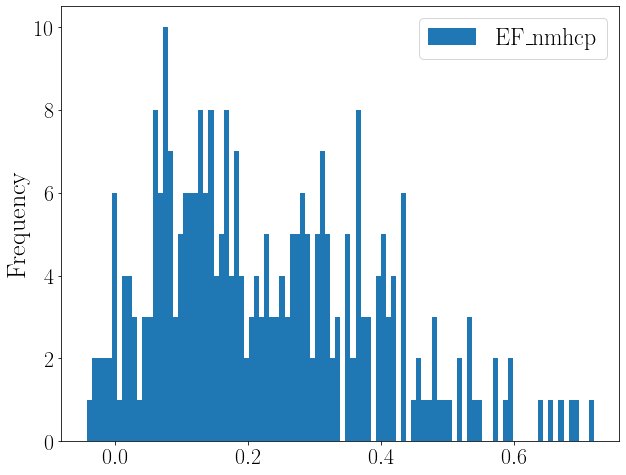

In [21]:
fig, ax =  plt.subplots()
for target_case in ['EF_nmhcp']:
    ax = BS[target_case].plot.hist(ax=ax, label = target_case, bins=100)
ax.legend()

chech that the chemistry resetting is correct!

In [22]:
ground_states

{('Fe_pv1', 'bcc', 'FM'): -8.255227964543023,
 ('Fe_pv2', 'hcp', 'NM'): -8.18407186323532,
 ('Fe_pv4', 'fcc', 'NM'): -8.105011456799609,
 ('Mo_sv1', 'bcc', 'FM'): -10.932754996062988,
 ('Mo_sv1', 'bcc', 'NM'): -10.932821158319513}

In [23]:
ground_state_samples = pd.Series(ground_states).index.map(lambda t: '.'.join(t))

In [24]:
ground_state_samples

Index(['Fe_pv1.bcc.FM', 'Fe_pv2.hcp.NM', 'Fe_pv4.fcc.NM', 'Mo_sv1.bcc.FM',
       'Mo_sv1.bcc.NM'],
      dtype='object')

In [25]:
BS.query('index.str.contains("fcc|bcc|hcp") and nelem==1')[['V0', 'E0', 'B0',target_case]]

,V0,E0,B0,EF_nmhcp
Fe_pv1.bcc.FM,11.356868,-8.255228,210.632901,0.000000
Fe_pv1.bcc.NM,10.481600,-7.790659,269.455898,0.393413
Fe_pv2.hcp.FM,12.029139,-8.065627,157.755333,0.189601
Fe_pv2.hcp.NM,10.193528,-8.184072,287.828951,0.000000
Fe_pv4.fcc-cubic.NM,10.247629,-8.105011,286.467141,0.079060
Mo_sv2.hcp.NM,16.145087,-10.497818,238.430509,0.435003
Mo_sv4.fcc-cubic.FM,16.053362,-10.513988,239.434172,0.418767
Mo_sv4.fcc-cubic.NM,16.058166,-10.513010,240.008475,0.419811
Fe_pv1.fcc.FM,12.021393,-8.107128,167.384487,0.148100
Mo_sv1.bcc.FM,15.825081,-10.932755,251.877901,0.000000


In [26]:
BS.to_pickle("Fe-Mo/FurtherCuratedParsedBriefSummary.pkl")

# guess structures: Define atomic volumes 

In [27]:
atom_volume_keys = {}
with  MPRester("XMK2lneoOyVOQDnhEnVmyX3h4dyJuSyo") as mpr:
    for atom, key in MP_keys.items():
        result =mpr.summary.search(material_ids=[key])[0]
        total_vol = result.volume
        nsites = result.nsites
        atom_volume_keys[atom] = total_vol/nsites

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
atom_volume_keys

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [29]:
Features = Featurizer(BS)

# Sort Poscar files

In [30]:
cases

['POSCAR.initial', 'POSCAR.relaxed-all']

In [31]:
for searchs, subcase in zip(cases, subcases):
#    searchs = 'POSCAR.initial'
    files = get_file_paths(dataset, searchs, csvfile=f'ListOfFiles_{searchs}.csv')

    atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
    sublatticesortersfile = os.path.join(atomsobjectslocation, f'SORTERS_{searchs}.pkl')
    sublatticetagfile = os.path.join(atomsobjectslocation, f'SUBLATICETAGS_{searchs}.pkl')

    if True: # not os.path.exists(sublatticesortersfile): # need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
        SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
        SORTERS.to_pickle(sublatticesortersfile)
        SUBLATICETAGS.to_pickle(sublatticetagfile)
    else:
        SORTERS = pd.read_pickle(sublatticesortersfile)
        SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

# Now I have to pick the atoms objects

In [32]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
#database = f'{dataset}/**/{case}'

In [33]:
Atoms_Objects = {}

In [34]:
subcases

['rescaled', 'noscaled']

In [35]:
for searchs, subcase in zip(cases, subcases):
    AtomsFile = os.path.join(atomsobjectslocation,f'{dataset}-{searchs}-{subcase}-AtomsObjects.pkl')
    if subcase == 'rescaled':
        booleanflag = True
    else:
        booleanflag = False
    if False : #not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
        Atoms_Objects[searchs] = pd.read_pickle(AtomsFile)
    else:
        Atoms_Objects[searchs], CantMake_Atoms_Object = Features.get_atoms_object(
            database=dataset,
            rescale_by_atoms=booleanflag,
            reset_chemistry=True,
            file_filter = searchs, #'initial$',
            element_volumes=atom_volume_keys
        )
        Atoms_Objects[searchs].to_pickle(AtomsFile)
        Atoms_Objects[searchs].dropna(inplace=True)
    pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
    Pymatgen_Structures = Atoms_Objects[searchs].copy()
    if False: # not need_to_update(pymatgenfile):
        Pymatgen_Structures = pd.read_pickle(pymatgenfile)
    else:
        Pymatgen_Structures = Atoms_Objects[searchs]['atoms'].apply(AseAtomsAdaptor.get_structure)
        Pymatgen_Structures['file'] = Atoms_Objects[searchs]['file']
        Pymatgen_Structures.to_pickle(pymatgenfile)

    accomodatewrap = Atoms_Objects[searchs].atoms.map(lambda a: a.wrap(pretty_translation=True))
    allindex = Atoms_Objects[searchs].index.intersection(BS.index)
    Atoms_Objects[searchs] = Atoms_Objects[searchs].loc[allindex]
    Atoms_Objects[searchs].to_pickle(AtomsFile)

  0%|          | 0/292 [00:00<?, ?it/s]

  0%|          | 0/292 [00:00<?, ?it/s]

In [36]:
for case, AtomsObject in Atoms_Objects.items():
    difference = BS.index.difference(AtomsObject.index)
    print(case, difference)

POSCAR.initial Index([], dtype='object')
POSCAR.relaxed-all Index([], dtype='object')


#  visualization of some structures

In [37]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [38]:
from ase.visualize.plot import plot_atoms

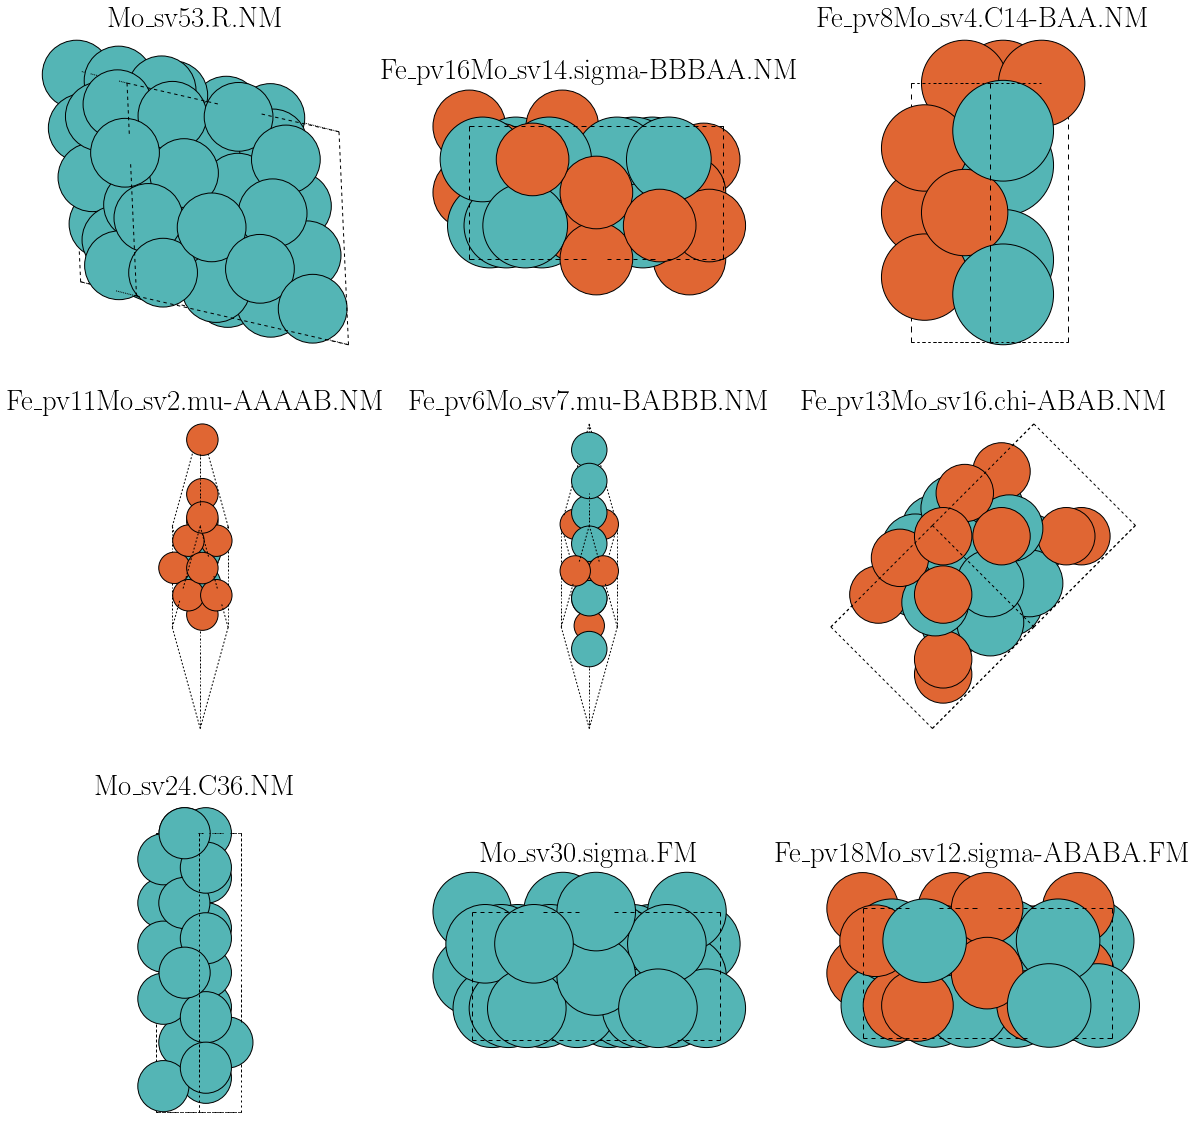

In [39]:
atoms_samples = Atoms_Objects['POSCAR.initial'].atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.items()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [40]:
somesigmas = Atoms_Objects['POSCAR.initial'].atoms[Atoms_Objects['POSCAR.initial'].index.str.contains('sigma')].sample(n=9)

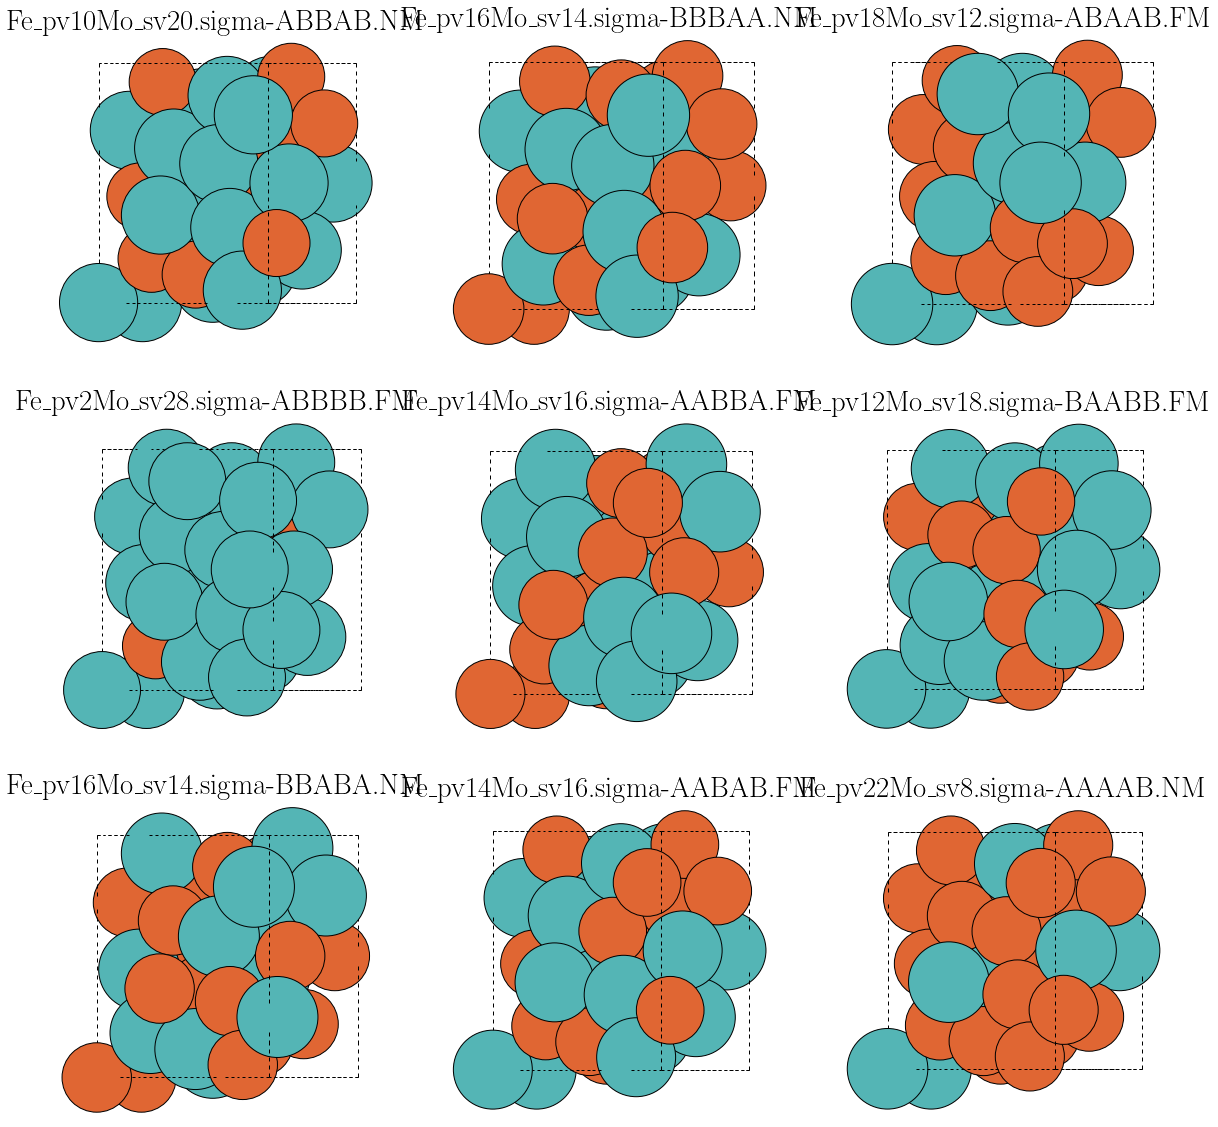

In [41]:
atoms_samples = Atoms_Objects['POSCAR.initial'].atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.items()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [42]:
Problems = BS.index.difference(Atoms_Objects['POSCAR.initial'].index)

In [43]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc


In [44]:
BS.dropna().describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366,0.250462,0.229052,0.205263
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605,0.161952,0.162156,0.166363
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000,-0.015446,-0.042841,-0.085488
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667,0.124923,0.102939,0.072821
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000,0.228259,0.196050,0.176500
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500,0.364194,0.336165,0.309251
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000,0.720532,0.720492,0.720492


In [45]:
GoodBS = BS.loc[Atoms_Objects['POSCAR.initial'].index]

In [46]:
GoodBS#.dropna()

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


In [47]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [48]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [49]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

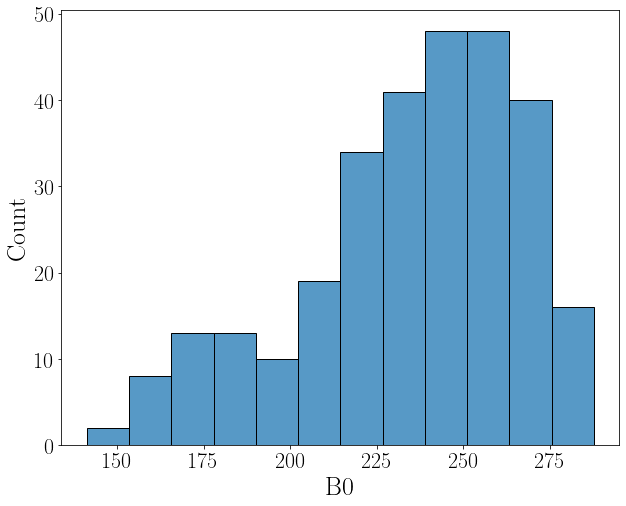

In [50]:
sns.histplot(BS['B0'])

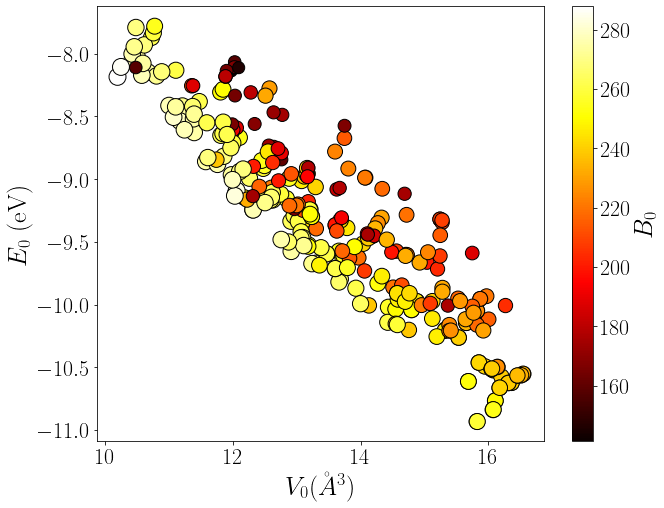

In [51]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

# Atomic volumes vs dft

In [52]:
BS.query('num_atoms == 1').groupby('E0').min('E0')#['V0']#reset_index()

,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
E0,,,,,,,,,,,
-10.932821,1,258.072533,15.828552,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.932755,1,251.877901,15.825081,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.511038,1,239.434813,16.058793,1,0,1,0.0,1.0,0.421784,0.421784,0.421784
-8.255228,1,210.632901,11.356868,1,0,1,1.0,0.0,0.000000,0.000000,0.000000
-8.107128,1,167.384487,12.021393,1,0,1,1.0,0.0,0.148100,0.148100,0.148100
-7.790659,1,269.455898,10.481600,1,0,1,1.0,0.0,0.464569,0.393413,0.314353


In [53]:
Fe_unary = BS.query('num_atoms == 1 and Fe_pv == 1')

In [54]:
V_GS_Fe = Fe_unary[Fe_unary.E0 == Fe_unary.E0.min()].V0

In [55]:
V_GS_Fe

Fe_pv1.bcc.FM    11.356868
Name: V0, dtype: float64

In [56]:
Mo_unary = BS.query('num_atoms == 1 and Mo_sv == 1')

In [57]:
V_GS_Mo = Mo_unary[Mo_unary.E0 == Mo_unary.E0.min()].V0

In [58]:
V_GS_Mo

Mo_sv1.bcc.NM    15.828552
Name: V0, dtype: float64

In [59]:
norm = plt.Normalize(BS['Fe_pv'].min(), BS['Fe_pv'].max())
sm = plt.cm.ScalarMappable(norm=norm, cmap='rainbow')
sm.set_array([])

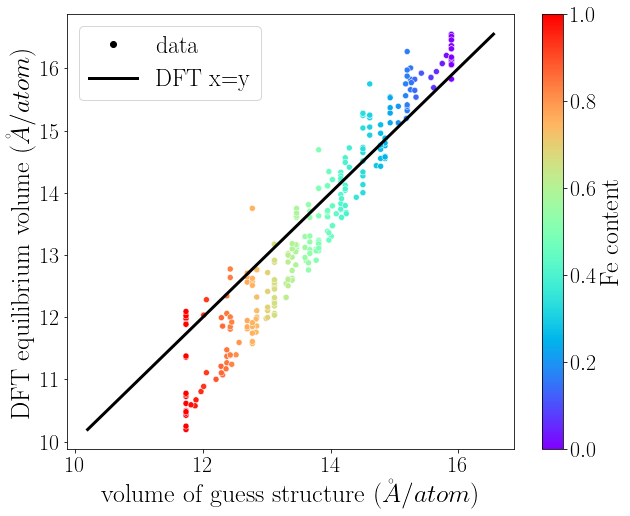

In [60]:
fig, axs = plt.subplots() #1, len(Atoms_Objects), figsize = (10,5), sharey=True)
#for (case, atoms_df), ax in zip(Atoms_Objects.items(), axs):
volumes = Atoms_Objects['POSCAR.initial']['atoms'].map(lambda a: a.get_volume()/a.get_global_number_of_atoms())
sns.scatterplot(x=volumes.values, y=BS['V0'].values, hue=BS['Fe_pv'], ax=axs, palette = 'rainbow', legend='brief', markers=BS.Phase)
#sns.lineplot(x=BS['V0'].values, y=BS['V0'].values,ax = axs, color='k', label='x=y', legend='brief')#, hue=BS['Fe_pv'], palette='rainbow')
axs.plot([BS['V0'].min(), BS['V0'].max()],[BS['V0'].min(), BS['V0'].max()], 'k' )
axs.set_ylabel(r'DFT equilibrium volume ($ \AA /atom $)')
axs.set_xlabel(r'volume of guess structure ($\AA / atom$)')
axs.legend().remove()
#ax.legend(['data', 'x=y'])
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', c='k'),
    plt.Line2D([0],[0],linestyle='-', c='k')
]
labels=[
    'data',
    'DFT x=y'
]
axs.legend(handles, labels)
#cbarax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
cbar = axs.figure.colorbar(sm) #, cax=cbarax)
cbar.set_label('Fe content')
#fig.tight_layout()
plt.savefig(f'{dataset}/graphs/{dataset}-dftV_vs_gressV.pdf')

In [61]:
colors = sns.color_palette('bright')

In [62]:
training_BS = BS.query('Phase != "bcc" & Phase != "hcp" & Phase != "fcc" & Phase != "R"')

In [63]:
colors

[(0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215),
 (0.6235294117647059, 0.2823529411764706, 0.0),
 (0.9450980392156862, 0.2980392156862745, 0.7568627450980392),
 (0.6392156862745098, 0.6392156862745098, 0.6392156862745098),
 (1.0, 0.7686274509803922, 0.0),
 (0.0, 0.8431372549019608, 1.0)]

In [95]:
phase_label = {
    'sigma': r"$\sigma$",
    'chi': r"$\chi$",
    'mu': r"$\mu$",
    'C36': 'C36',
    'C14': 'C14',
    'C15': 'C15',
    'A15': 'A15',
    'R': 'R',
    'lambda': r"$\lambda$ (C14)"
}

[Text(0, 0, 'C36'), Text(0, 1, 'mu'), Text(0, 2, 'sigma'), Text(0, 3, 'C14'), Text(0, 4, 'chi'), Text(0, 5, 'C15'), Text(0, 6, 'A15')]
['C36', '$\\mu$', '$\\sigma$', 'C14', '$\\chi$', 'C15', 'A15']


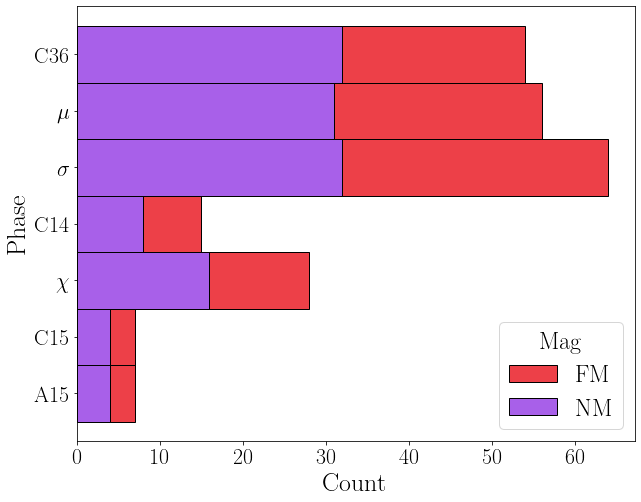

In [65]:
fig, ax = plt.subplots()
sns.histplot(training_BS, y='Phase', hue='Mag', multiple='stack', palette=[colors[3], colors[4]], ax = ax)
ticks = ax.get_yticklabels()
#ax.set_xticklabels(ticklabels)
fig.savefig('Fe-Mo/graphs/Fe-Mo_StackCounts_Sanitized.pdf')
print(ticks)
new_ticks = [phase_label[label._text] for label in ticks if label._text != '']
print(new_ticks)
ax.set_yticklabels(new_ticks)
fig.savefig('Fe-Mo/graphs/Fe-Mo_StackCounts_Sanitized.pdf')


# convex hulls 

In [66]:
from Tools.DatasetTools.Tools import Plotting

In [67]:
phases = BS.Phase.unique()

In [68]:
CHULL = {}

In [69]:
P = Plotting()

In [70]:
for phase, bs_phase in BS.groupby(by='Phase'):
    CHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp'))

In [71]:
colors = colormaps['tab20'].colors

In [72]:
xy = {}

In [73]:
color_seq = {}
#for (phase, chull), c in zip ( CHULL.items(), colors ):
for phase, chull in CHULL.items(): #, colors ):
    if phase == 'bcc':
        continue
    if phase == 'fcc':
        continue
    if phase == 'hcp':
        continue
    if phase == 'chi':
        continue
#    if phase == 'R':
#        continue
    bs_phase = BS[BS.Phase == phase]
    vertices = np.unique( chull.simplices[chull.good])
    xy[phase]= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
#    l = ax.plot(xy[phase]['Fe_pv'].values, xy[phase][target_case].values, label = phase_label[phase])#, color=c)
#    ax.scatter(bs_phase['Fe_pv'], bs_phase[target_case], s=100, edgecolor='k', linewidth=2)#, facecolor=c)
#    color_seq[phase] = l[0].get_color()
#ax.legend(bbox_to_anchor=(1,1))
#ax.axhline(c='k', ls='--')
#ax.set_xlabel ('$x_{Fe}$')
#ax.set_xlim([0,1])
#ax.set_ylabel('$\Delta E_F$')

In [74]:
from scipy.interpolate import interp1d

In [75]:
interpolation_y = {}
x = np.linspace(0,1,100)

In [76]:
for phase, this_xy in xy.items():
    interpolation = interp1d(this_xy['Fe_pv'], this_xy[target_case])
    interpolation_y[phase]=interpolation(x)

In [77]:
compare_chulls = pd.DataFrame.from_dict(interpolation_y)

In [78]:
phase_range = {}

In [79]:
for phase in compare_chulls:
    mask = compare_chulls[phase].le(compare_chulls.min(axis=1))
    phase_range[phase] = x[mask]

In [80]:
alphas = {
    'lambda': 1,
    'R':0.3,
    'sigma': 0.3,
    'mu': 0.3
}

In [81]:
experimental_range = {
    'sigma': [0.4,0.55],
    'R' : [0.6,0.65],
    'mu' : [0.6, 0.55],
    'lambda': [0.655, 0.66]
}

In [82]:
#color_seq['R'] = 'grey'

In [83]:
pallete_seq = sns.color_palette('tab10', len(CHULL))
color_seq = {phase: color for phase, color in zip(CHULL.keys(), pallete_seq)}
color_seq['lambda'] = '#000000'

In [84]:
CHULL.keys()

dict_keys(['A15', 'C14', 'C15', 'C36', 'R', 'bcc', 'chi', 'fcc', 'hcp', 'mu', 'sigma'])

In [85]:
marker_seq = {'A15': 'p', 'C14': 'X','C15':9, 'C36': 'o', 'R': 'h', 'bcc':'.', 'chi': 'D', 'fcc': '>', 'hcp':'<', 'mu': 'D', 'sigma': 's'}

In [86]:
from matplotlib.lines import Line2D

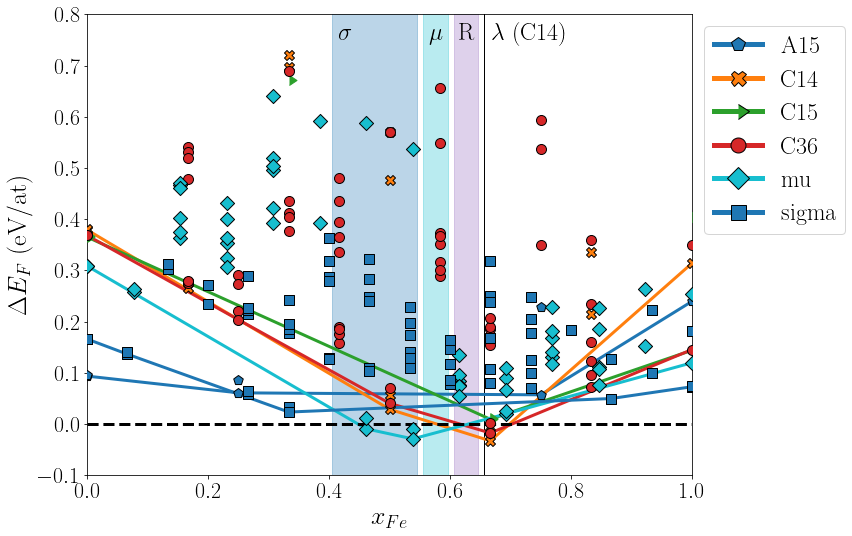

In [100]:

fig = plt.figure(figsize=(12,8))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.8])
#for (phase, chull), c in zip ( CHULL.items(), colors ):
handles = []
labels = []
for phase, chull in CHULL.items(): #, colors ):
    if phase in ['bcc', 'fcc', 'hcp', 'chi', 'R']:
        continue
    bs_phase = BS[BS.Phase == phase]
    vertices = np.unique( chull.simplices[chull.good])
    xy[phase]= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
    ax.plot(xy[phase]['Fe_pv'].values, xy[phase][target_case].values,  color=color_seq[phase]) #label = phase_label[phase],
    handles.append(Line2D([0],[0], color=color_seq[phase], linewidth=5, marker = marker_seq[phase], markersize=15, markeredgecolor='k'))
    labels.append(phase)
for phase, bs_phase in BS.groupby('Phase'):
    if phase in ['bcc', 'fcc', 'hcp', 'chi', 'R']:
        continue
    ax.scatter(bs_phase['Fe_pv'], bs_phase[target_case], s=100, edgecolor='k',marker=marker_seq[phase], linewidth=1, facecolor=color_seq[phase], zorder=10)
#    color_seq[phase] = l[0].get_color()
for label, trange in  experimental_range.items():
    xmin = min(trange)
    xmax = max(trange)
    this_x = x[ ( x< xmax ) & ( x>xmin )]
    ax.fill_between(this_x,-0.1, 1, alpha = alphas[label], color = color_seq[label])
    ax.annotate(phase_label[label], (xmin+0.015, 0.75))
ax.legend(handles, labels, bbox_to_anchor=(1, 1))
ax.axhline(c='k', ls='--')
ax.set_xlabel ('$x_{Fe}$')
ax.set_xlim([0,1])
ax.set_ylim([-0.1, 0.8])
ax.set_ylabel('$\Delta E_F$ (eV/at)')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_ConvexHulls_ExpRanges.pdf')